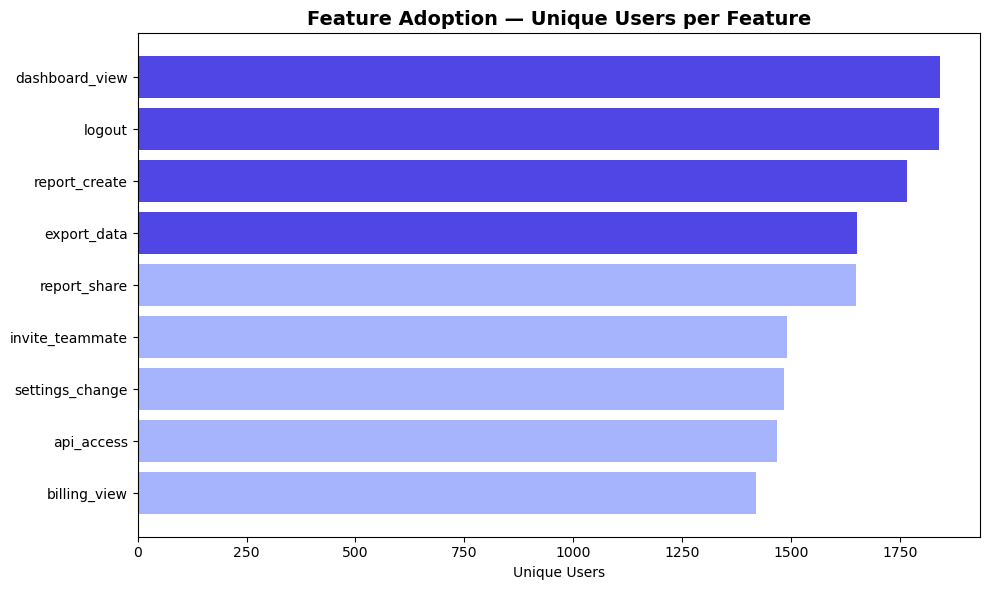

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r'C:\Users\Soumili Nag\OneDrive\Desktop\projects\SaaS Product Analytics\data\saas_events.csv')

# Feature usage count
feature_usage = (df[df['event_name'] != 'login']
                 .groupby('event_name')['user_id']
                 .nunique()
                 .sort_values(ascending=True)
                 .reset_index())
feature_usage.columns = ['feature', 'unique_users']

# Feature adoption by plan
adoption_by_plan = (df.groupby(['plan','event_name'])['user_id']
                    .nunique()
                    .reset_index())

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#4F46E5' if u > feature_usage['unique_users'].median() 
          else '#A5B4FC' for u in feature_usage['unique_users']]
ax.barh(feature_usage['feature'], feature_usage['unique_users'], color=colors)
ax.set_title('Feature Adoption — Unique Users per Feature', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Unique Users')
plt.tight_layout()
plt.savefig(r'C:\Users\Soumili Nag\OneDrive\Desktop\projects\SaaS Product Analytics\images\feature_adoption.png', dpi=150)
plt.show()